In [1]:
pip install ydata_profiling 

Note: you may need to restart the kernel to use updated packages.


ERROR: Ignored the following versions that require a different python version: 4.0.0 Requires-Python >=3.7,<3.11; 4.1.0 Requires-Python >=3.7,<3.12; 4.1.1 Requires-Python >=3.7,<3.12; 4.1.2 Requires-Python >=3.7,<3.12; 4.10.0 Requires-Python >=3.7,<3.13; 4.11.0 Requires-Python >=3.7,<3.13; 4.12.0 Requires-Python >=3.7,<3.13; 4.12.1 Requires-Python >=3.7,<3.13; 4.12.2 Requires-Python >=3.7,<3.13; 4.13.0 Requires-Python >=3.7,<3.13; 4.14.0 Requires-Python >=3.7,<3.13; 4.15.0 Requires-Python >=3.7,<3.13; 4.15.1 Requires-Python >=3.7,<3.13; 4.16.0 Requires-Python >=3.7,<3.13; 4.16.1 Requires-Python >=3.7,<3.13; 4.17.0 Requires-Python >=3.7,<3.14; 4.18.0 Requires-Python >=3.10,<3.14; 4.18.1 Requires-Python >=3.10,<3.14; 4.18.4 Requires-Python >=3.10,<3.14; 4.2.0 Requires-Python >=3.7,<3.12; 4.3.0 Requires-Python >=3.7,<3.12; 4.3.1 Requires-Python >=3.7,<3.12; 4.3.2 Requires-Python >=3.7,<3.12; 4.4.0 Requires-Python >=3.7,<3.12; 4.5.0 Requires-Python >=3.7,<3.12; 4.5.1 Requires-Python >=3.7,

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
#from ydata_profiling import ProfileReport
from sklearn.preprocessing import StandardScaler,LabelEncoder,OneHotEncoder,OrdinalEncoder
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
import pickle 
import warnings 
warnings.filterwarnings('ignore')

In [3]:
pip install pandas 

Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install numpay 

Note: you may need to restart the kernel to use updated packages.


In [5]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [6]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [7]:
df=pd.read_csv("loan_approved.csv")

In [8]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status (Approved)
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [9]:
df.isnull().sum() 
#used to find the number of missing

Loan_ID                    0
Gender                    13
Married                    3
Dependents                15
Education                  0
Self_Employed             32
ApplicantIncome            0
CoapplicantIncome          0
LoanAmount                22
Loan_Amount_Term          14
Credit_History            50
Property_Area              0
Loan_Status (Approved)     0
dtype: int64

In [10]:
df['Gender'].value_counts()

Gender
Male      489
Female    112
Name: count, dtype: int64

In [11]:
#used to replace missing (null) values
df.loc[df['Gender'].isnull(),'Gender']="Male"

In [12]:
df.Gender.isnull().sum()

np.int64(0)

In [13]:
df.loc[df['Credit_History'].isnull(),'Credit_History']=0.0

In [14]:
df.loc[df['LoanAmount'].isnull(),'LoanAmount']=df['LoanAmount'].median()

In [15]:
df['Married'].value_counts()

Married
Yes    398
No     213
Name: count, dtype: int64

<Axes: xlabel='ApplicantIncome'>

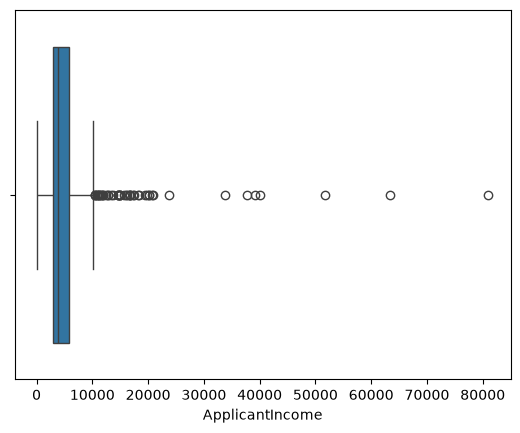

In [16]:
#Used to find outliers
sns.boxplot(x=df.ApplicantIncome,orient='h')

In [17]:
df.loc[df['Married'].isnull(),'Married']="Yes"

In [18]:
df.isnull().sum()

Loan_ID                    0
Gender                     0
Married                    0
Dependents                15
Education                  0
Self_Employed             32
ApplicantIncome            0
CoapplicantIncome          0
LoanAmount                 0
Loan_Amount_Term          14
Credit_History             0
Property_Area              0
Loan_Status (Approved)     0
dtype: int64

In [19]:
df.loc[df['Self_Employed'].isnull(),'Self_Employed']="No"

In [20]:
df.loc[df['Loan_Amount_Term'].isnull(),'Loan_Amount_Term']=360.0

In [21]:
df.loc[df['Dependents'].isnull(),'Dependents']='0'

In [22]:
df.isnull().sum()

Loan_ID                   0
Gender                    0
Married                   0
Dependents                0
Education                 0
Self_Employed             0
ApplicantIncome           0
CoapplicantIncome         0
LoanAmount                0
Loan_Amount_Term          0
Credit_History            0
Property_Area             0
Loan_Status (Approved)    0
dtype: int64

In [23]:
from scipy.stats.mstats import winsorize
#specify the percentage of data to be trimned from both ends
trim_percentage=0.08
#winsorize the Specifide culomn
df['ApplicantIncome']=winsorize(df['ApplicantIncome'],limits=trim_percentage)

<Axes: xlabel='ApplicantIncome'>

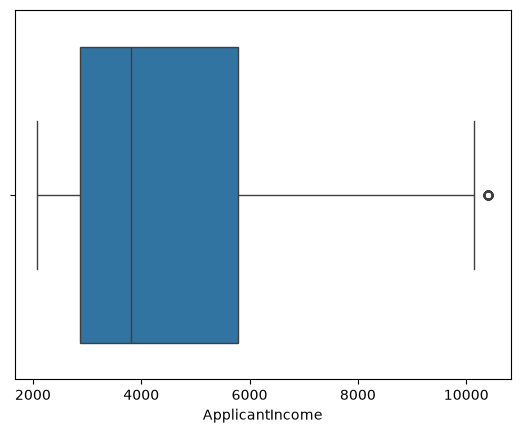

In [24]:
sns.boxplot(x=df.ApplicantIncome,orient='h')

In [25]:
Q1=df['LoanAmount'].quantile(0.25)
Q3=df['LoanAmount'].quantile(0.75)

In [26]:
IQR=Q3-Q1
IQR

np.float64(64.5)

In [27]:
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR

In [28]:
print(lower_bound)
print(upper_bound)


3.5
261.5


In [29]:
df=df[(df['LoanAmount']>=lower_bound)&(df['LoanAmount']<=upper_bound)]

<Axes: xlabel='LoanAmount'>

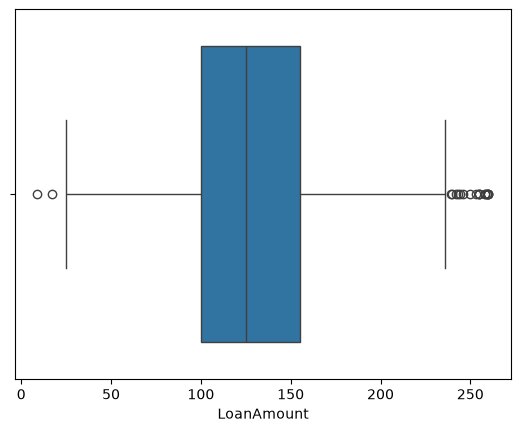

In [30]:
sns.boxplot(x=df.LoanAmount,orient='h')

In [31]:
#using one hot Encoding

In [32]:
df_encoded=pd.get_dummies(df,columns=['Married'],prefix='Married')# adding the columns in the data 

In [33]:
df_encoded.columns

Index(['Loan_ID', 'Gender', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area',
       'Loan_Status (Approved)', 'Married_No', 'Married_Yes'],
      dtype='str')

In [34]:
df_encoded

,Loan_ID,Gender,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status (Approved),Married_No,Married_Yes
0,LP001002,Male,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y,True,False
1,LP001003,Male,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N,False,True
2,LP001005,Male,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y,False,True
3,LP001006,Male,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y,False,True
4,LP001008,Male,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y,True,False
610,LP002979,Male,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y,False,True
611,LP002983,Male,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y,False,True
612,LP002984,Male,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y,False,True


In [35]:
#label encoding

In [36]:
encoder=LabelEncoder()
df['Marrried']=encoder.fit_transform(df['Married'])
print(df[['Married']])

    Married
0        No
1       Yes
2       Yes
3       Yes
4        No
..      ...
609      No
610     Yes
611     Yes
612     Yes
613      No

[573 rows x 1 columns]


# odinal Encoder

In [37]:
df.Education.value_counts()

Education
Graduate        440
Not Graduate    133
Name: count, dtype: int64

In [38]:
Education_enc=OrdinalEncoder(categories=[['Graduate' 'Non Graduate']])

In [39]:
df['Education']=encoder.fit_transform(df['Education'])

#  transformating 

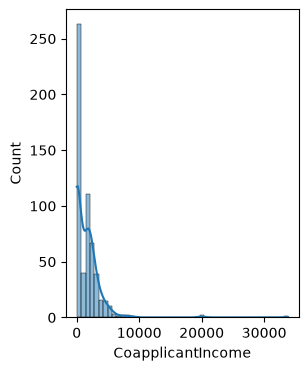

In [40]:
plt.figure(figsize=(3,4))
sns.histplot(x=df['CoapplicantIncome'],kde=True)
plt.show()

In [41]:
df.Education.value_counts()

Education
0    440
1    133
Name: count, dtype: int64

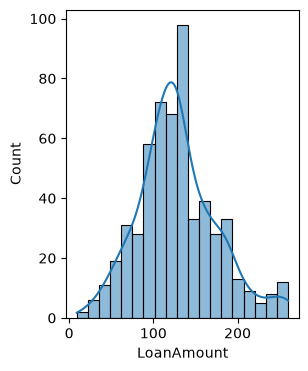

In [42]:
plt.figure(figsize=(3,4))
sns.histplot(x=df['LoanAmount'],kde=True)
plt.show()

# uing the log transformating 

In [43]:
df['CoapplicantIncome']=np.log(df['CoapplicantIncome'])

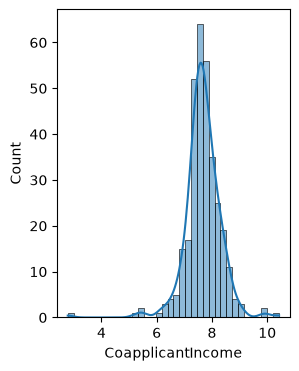

In [44]:
plt.figure(figsize=(3,4))
sns.histplot(x=df['CoapplicantIncome'],kde=True)
plt.show()

# using the Exponential Transformers

In [45]:
df['ApplicantIncome_exponential']=df.ApplicantIncome**(1/1.2)

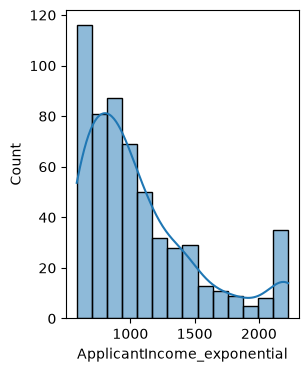

In [46]:
plt.figure(figsize=(3,4))
sns.histplot(x=df['ApplicantIncome_exponential'],kde=True)
plt.show()

# usingBox Cox transformation

In [47]:
from scipy.stats import boxcox
transformed_data,lambda_value=boxcox(df['Loan_Amount_Term'])

In [48]:
print("Transformed data:",transformed_data)

Transformed data: [1.72400389e+07 1.72400389e+07 1.72400389e+07 1.72400389e+07
 1.72400389e+07 1.72400389e+07 1.72400389e+07 1.72400389e+07
 1.72400389e+07 1.72400389e+07 1.72400389e+07 1.72400389e+07
 6.25636008e+05 1.72400389e+07 5.06987490e+06 1.72400389e+07
 1.72400389e+07 1.72400389e+07 1.72400389e+07 1.72400389e+07
 1.72400389e+07 1.72400389e+07 1.72400389e+07 1.72400389e+07
 1.72400389e+07 1.72400389e+07 1.72400389e+07 1.72400389e+07
 1.72400389e+07 1.72400389e+07 1.72400389e+07 1.72400389e+07
 1.72400389e+07 1.72400389e+07 1.72400389e+07 1.72400389e+07
 1.72400389e+07 1.72400389e+07 1.72400389e+07 1.72400389e+07
 1.72400389e+07 1.72400389e+07 1.72400389e+07 1.72400389e+07
 1.72400389e+07 1.72400389e+07 1.72400389e+07 1.72400389e+07
 1.72400389e+07 1.72400389e+07 1.72400389e+07 1.72400389e+07
 1.72400389e+07 1.72400389e+07 1.72400389e+07 1.72400389e+07
 1.72400389e+07 2.12746722e+06 1.72400389e+07 1.72400389e+07
 1.72400389e+07 2.12746722e+06 7.72048881e+04 1.72400389e+07
 1.724

In [49]:
print("Lambda value:",lambda_value)

Lambda value: 3.0185540252193874


# using Square root Transformation

In [50]:
df['LoanAmount']=df.LoanAmount**(1/2)

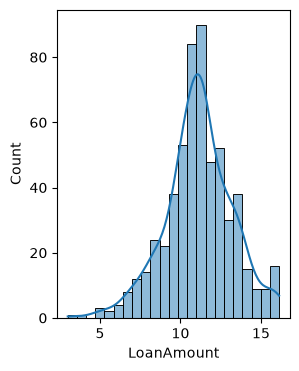

In [51]:
plt.figure(figsize=(3,4))
sns.histplot(x=df['LoanAmount'],kde=True)
plt.show()

# using the Standard Scalar

In [52]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area',
       'Loan_Status (Approved)', 'Marrried', 'ApplicantIncome_exponential'],
      dtype='str')

In [56]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
ApplicantIncome_scaled=scaler.fit_transform(df[['ApplicantIncome']])

In [57]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
ApplicantIncome_scaled2=scaler.fit_transform(df[['ApplicantIncome']])

# Using Robust Scalar

In [60]:
from sklearn.preprocessing import RobustScaler
scaler=RobustScaler()
ApplicantIncome_scaled3=scaler.fit_transform(df[['ApplicantIncome']])